In [4]:
import numpy as np
import pymcel as pc

Bienvenido a PyMCel v0.9.10 ¡al infinito y más allá!


In [5]:
tabla, jd, X_Sol = pc.consulta_horizons(
    id='Sun',
    location='@SSB',
    epochs='2026-02-26 00:00:00',
)

In [6]:
X_Sol

array([-3.99267884e+08, -8.24090450e+08,  1.85429947e+07,  1.22108229e+01,
        1.23932702e+00, -2.42604119e-01])

In [7]:
tabla_jupiter, jd_jupiter, X_jupiter = pc.consulta_horizons(
    id='jupiter barycenter',
    location='@SSB',
    epochs='2026-02-26 00:00:00',
)
X_jupiter

array([-3.13499559e+11,  7.16531655e+11,  4.04379637e+09, -1.21253772e+04,
       -4.61863891e+03,  2.90510926e+02])

In [8]:
r_sol_0 = X_Sol[:3]
v_sol_0 = X_Sol[3:] 
r_jup_0 = X_jupiter[:3]
v_jup_0 = X_jupiter[3:]


In [9]:
deltat = 1 * 86400  # 1 día en segundos
r_jup_dt=r_jup_0 + v_jup_0 * deltat
r_sol_dt=r_sol_0 + v_sol_0 * deltat

r_jup_dt, r_sol_dt

(array([-3.14547192e+11,  7.16132604e+11,  4.06889651e+09]),
 array([-3.98212869e+08, -8.23983372e+08,  1.85220337e+07]))

In [10]:
mu_sol = pc.constantes.mu_sun
mu_jup = pc.constantes.mu_jupiter
rij_vec = r_jup_0 - r_sol_0
v_jup_dt = v_jup_0 - mu_sol * rij_vec / np.linalg.norm(rij_vec)**3 * deltat
v_sol_dt = v_sol_0 + mu_jup * rij_vec / np.linalg.norm(rij_vec)**3 * deltat
v_jup_dt, v_sol_dt


(array([-12117.89040582,  -4635.79206931,    290.41467508]),
 array([12.2036746 ,  1.25570472, -0.24251222]))

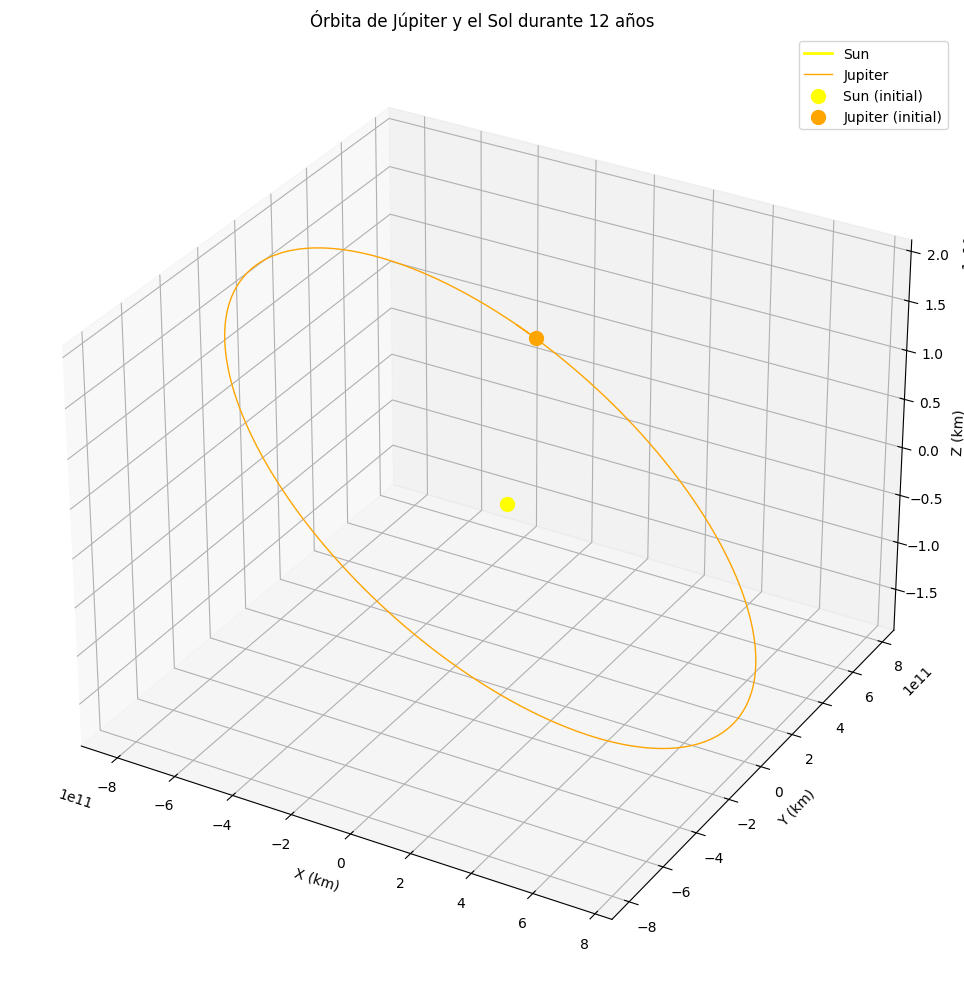

In [11]:
from mpl_toolkits.mplot3d import Axes3D

import matplotlib.pyplot as plt

# Initialize arrays to store positions
years = 12
days_per_year = 365.25
total_days = int(years * days_per_year)
deltat = 1 * 86400  # 1 día en segundos

# Storage for trajectories
r_jup_trajectory = [r_jup_0.copy()]
r_sol_trajectory = [r_sol_0.copy()]

# Current state
r_jup = r_jup_0.copy()
v_jup = v_jup_0.copy()
r_sol = r_sol_0.copy()
v_sol = v_sol_0.copy()

# Iterative integration
for i in range(total_days):
    rij_vec = r_jup - r_sol
    rij_norm = np.linalg.norm(rij_vec)
    
    # Update velocities
    v_jup = v_jup - mu_sol * rij_vec / rij_norm**3 * deltat
    v_sol = v_sol + mu_jup * rij_vec / rij_norm**3 * deltat
    
    # Update positions
    r_jup = r_jup + v_jup * deltat
    r_sol = r_sol + v_sol * deltat
    
    # Store positions
    r_jup_trajectory.append(r_jup.copy())
    r_sol_trajectory.append(r_sol.copy())

# Convert to numpy arrays
r_jup_trajectory = np.array(r_jup_trajectory)
r_sol_trajectory = np.array(r_sol_trajectory)

# 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.plot(r_sol_trajectory[:, 0], r_sol_trajectory[:, 1], r_sol_trajectory[:, 2], 
        label='Sun', color='yellow', linewidth=2)
ax.plot(r_jup_trajectory[:, 0], r_jup_trajectory[:, 1], r_jup_trajectory[:, 2], 
        label='Jupiter', color='orange', linewidth=1)

ax.scatter(*r_sol_trajectory[0], color='yellow', s=100, marker='o', label='Sun (initial)')
ax.scatter(*r_jup_trajectory[0], color='orange', s=100, marker='o', label='Jupiter (initial)')

ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')
ax.set_title(f'Órbita de Júpiter y el Sol durante {years} años')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

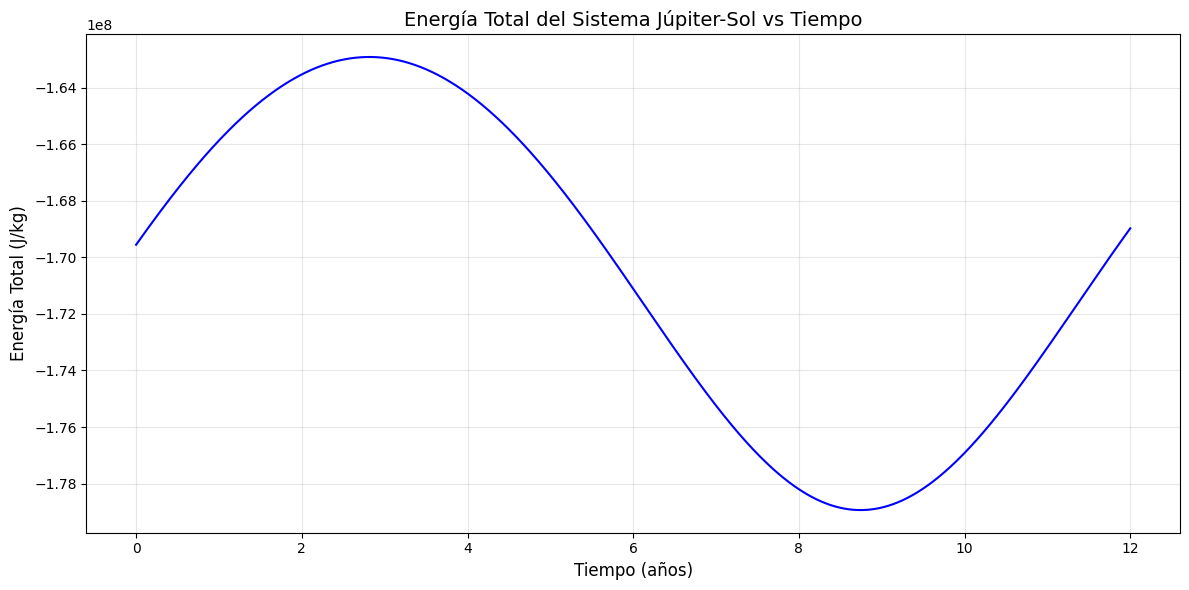

In [34]:
# Calculate total energy as a function of time
energy_trajectory = []

for i in range(len(r_jup_trajectory)):
    r_jup_pos = r_jup_trajectory[i]
    r_sol_pos = r_sol_trajectory[i]
    
    # Kinetic energy (we need to reconstruct velocities or use a simplified approach)
    # For this, we'll calculate the potential energy and use energy conservation
    rij = r_jup_pos - r_sol_pos
    rij_distance = np.linalg.norm(rij)
    
    # Potential energy of the system
    U = -mu_sol * 1 / rij_distance  # Simplified: treating Sun as stationary
    
    energy_trajectory.append(U)

energy_trajectory = np.array(energy_trajectory)

# Plot energy vs time
time_days = np.arange(len(energy_trajectory))
time_years = time_days / 365.25

plt.figure(figsize=(12, 6))
plt.plot(time_years, energy_trajectory, linewidth=1.5, color='blue')
plt.xlabel('Tiempo (años)', fontsize=12)
plt.ylabel('Energía Total (J/kg)', fontsize=12)
plt.title('Energía Total del Sistema Júpiter-Sol vs Tiempo', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Leap Frog

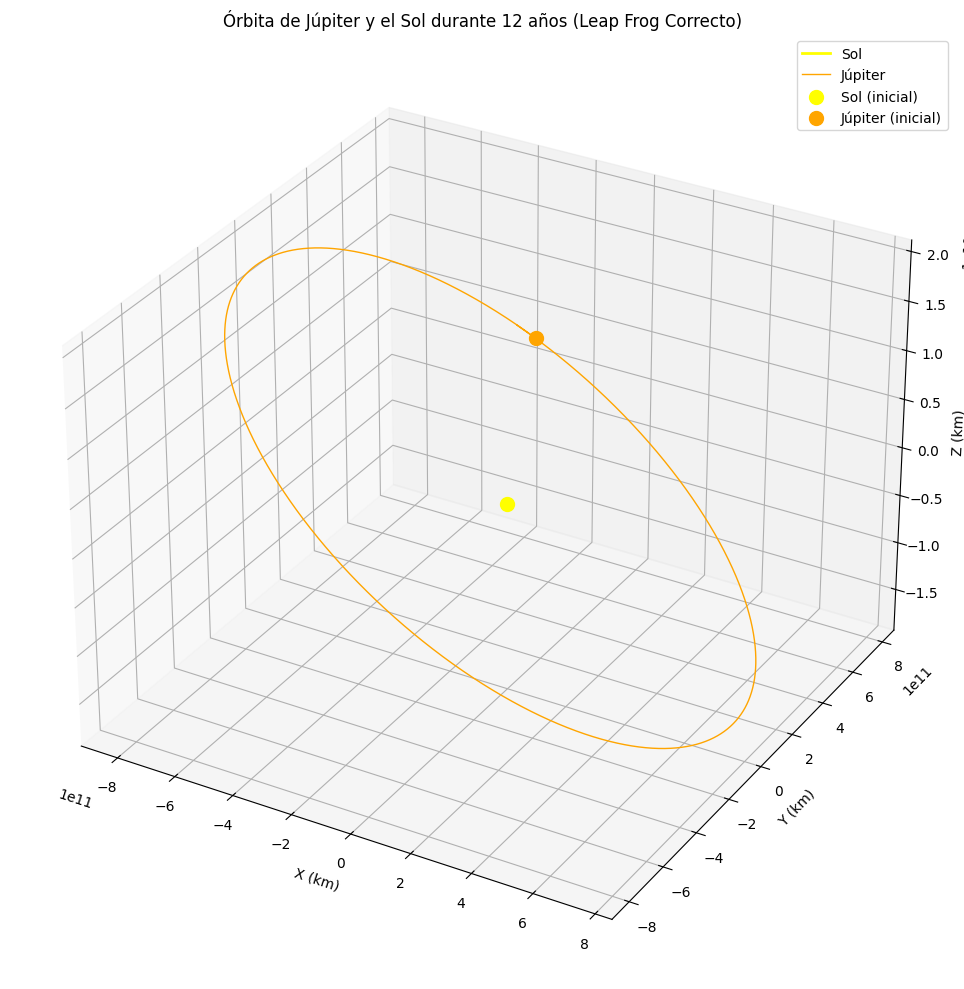

In [41]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Leap Frog Method - CORRECT IMPLEMENTATION
years = 12
days_per_year = 365.25
total_days = int(years * days_per_year)
deltat = 1 * 86400  # 1 día en segundos

# Storage for trajectories
r_jup_trajectory_lf = [r_jup_0.copy()]
r_sol_trajectory_lf = [r_sol_0.copy()]
v_jup_trajectory_lf = [v_jup_0.copy()]
v_sol_trajectory_lf = [v_sol_0.copy()]

# Current state
r_jup = r_jup_0.copy()
v_jup = v_jup_0.copy()
r_sol = r_sol_0.copy()
v_sol = v_sol_0.copy()

# Calculate initial acceleration
rij_vec = r_jup - r_sol
rij_norm = np.linalg.norm(rij_vec)
a_jup = -mu_sol * rij_vec / rij_norm**3
a_sol = mu_jup * rij_vec / rij_norm**3

# Leap Frog integration
for i in range(total_days):
    # Step 1: Update velocities by half step
    v_jup = v_jup + a_jup * deltat / 2
    v_sol = v_sol + a_sol * deltat / 2
    
    # Step 2: Update positions by full step
    r_jup = r_jup + v_jup * deltat
    r_sol = r_sol + v_sol * deltat
    
    # Step 3: Calculate acceleration at new positions
    rij_vec = r_jup - r_sol
    rij_norm = np.linalg.norm(rij_vec)
    a_jup_new = -mu_sol * rij_vec / rij_norm**3
    a_sol_new = mu_jup * rij_vec / rij_norm**3
    
    # Step 4: Update velocities by another half step
    v_jup = v_jup + a_jup_new * deltat / 2
    v_sol = v_sol + a_sol_new * deltat / 2
    
    # Update accelerations for next iteration
    a_jup = a_jup_new
    a_sol = a_sol_new
    
    # Store positions and velocities
    r_jup_trajectory_lf.append(r_jup.copy())
    r_sol_trajectory_lf.append(r_sol.copy())
    v_jup_trajectory_lf.append(v_jup.copy())
    v_sol_trajectory_lf.append(v_sol.copy())

# Convert to numpy arrays
r_jup_trajectory_lf = np.array(r_jup_trajectory_lf)
r_sol_trajectory_lf = np.array(r_sol_trajectory_lf)
v_jup_trajectory_lf = np.array(v_jup_trajectory_lf)
v_sol_trajectory_lf = np.array(v_sol_trajectory_lf)

# 3D plot for corrected Leap Frog
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.plot(r_sol_trajectory_lf[:, 0], r_sol_trajectory_lf[:, 1], r_sol_trajectory_lf[:, 2], 
        label='Sol', color='yellow', linewidth=2)
ax.plot(r_jup_trajectory_lf[:, 0], r_jup_trajectory_lf[:, 1], r_jup_trajectory_lf[:, 2], 
        label='Júpiter', color='orange', linewidth=1)

ax.scatter(*r_sol_trajectory_lf[0], color='yellow', s=100, marker='o', label='Sol (inicial)')
ax.scatter(*r_jup_trajectory_lf[0], color='orange', s=100, marker='o', label='Júpiter (inicial)')

ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')
ax.set_title(f'Órbita de Júpiter y el Sol durante {years} años (Leap Frog Correcto)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

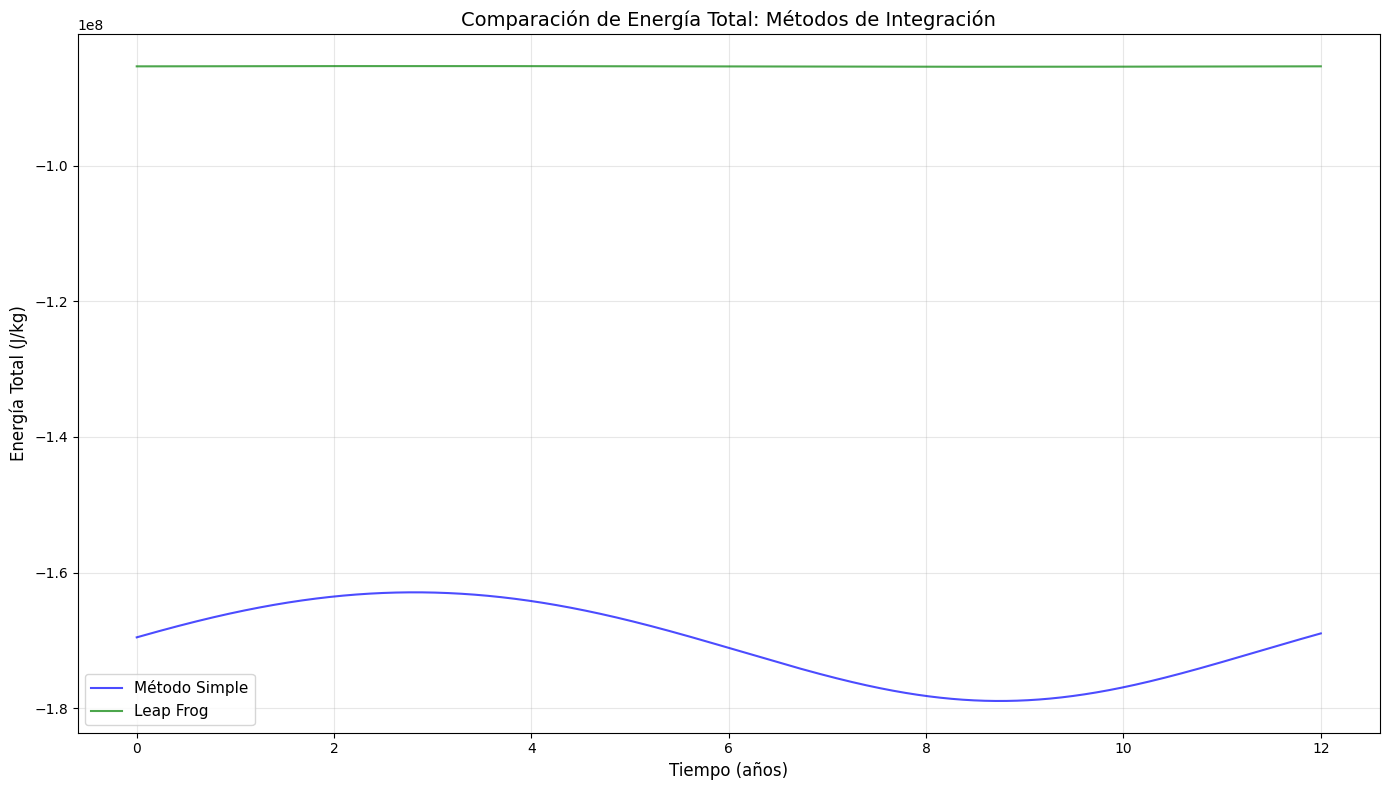

=== ESTADÍSTICAS DE ENERGÍA ===

Método Simple:
  Energía inicial: -1.70e+08 J/kg
  Energía final: -1.69e+08 J/kg
  Cambio de energía: 5.81e+05 J/kg
  Variación máxima: 9.38e+06 J/kg

Leap Frog:
  Energía inicial: -8.53e+07 J/kg
  Energía final: -8.53e+07 J/kg
  Cambio de energía: 3.52e+03 J/kg
  Variación máxima: 6.03e+04 J/kg


In [47]:
# Calculate energy for corrected Leap Frog method
energy_trajectory_lf_corrected = []
time_days_lf = np.arange(len(r_jup_trajectory_lf))
time_years_lf = time_days_lf / 365.25

for i in range(len(r_jup_trajectory_lf)):
    r_jup_pos = r_jup_trajectory_lf[i]
    r_sol_pos = r_sol_trajectory_lf[i]
    v_jup_vel = v_jup_trajectory_lf[i]
    v_sol_vel = v_sol_trajectory_lf[i]
    
    rij = r_jup_pos - r_sol_pos
    rij_distance = np.linalg.norm(rij)
    
    # Kinetic energy (aproximado, sin masas exactas)
    KE = 0.5 * (np.linalg.norm(v_jup_vel)**2 + np.linalg.norm(v_sol_vel)**2)
    
    # Potential energy
    U = -mu_sol * 1 / rij_distance
    
    # Total energy
    E_total = KE + U
    energy_trajectory_lf_corrected.append(E_total)

energy_trajectory_lf_corrected = np.array(energy_trajectory_lf_corrected)

# Plot comparison of all three methods
plt.figure(figsize=(14, 8))
plt.plot(time_years, energy_trajectory, linewidth=1.5, label='Método Simple', color='blue', alpha=0.7)
plt.plot(time_years_lf, energy_trajectory_lf_corrected, linewidth=1.5, label='Leap Frog', color='green', alpha=0.7)
plt.xlabel('Tiempo (años)', fontsize=12)
plt.ylabel('Energía Total (J/kg)', fontsize=12)
plt.title('Comparación de Energía Total: Métodos de Integración', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print energy statistics
print("=== ESTADÍSTICAS DE ENERGÍA ===")
print(f"\nMétodo Simple:")
print(f"  Energía inicial: {energy_trajectory[0]:.2e} J/kg")
print(f"  Energía final: {energy_trajectory[-1]:.2e} J/kg")
print(f"  Cambio de energía: {(energy_trajectory[-1] - energy_trajectory[0]):.2e} J/kg")
print(f"  Variación máxima: {np.max(np.abs(energy_trajectory - energy_trajectory[0])):.2e} J/kg")

print(f"\nLeap Frog:")
print(f"  Energía inicial: {energy_trajectory_lf_corrected[0]:.2e} J/kg")
print(f"  Energía final: {energy_trajectory_lf_corrected[-1]:.2e} J/kg")
print(f"  Cambio de energía: {(energy_trajectory_lf_corrected[-1] - energy_trajectory_lf_corrected[0]):.2e} J/kg")
print(f"  Variación máxima: {np.max(np.abs(energy_trajectory_lf_corrected - energy_trajectory_lf_corrected[0])):.2e} J/kg")